# Pneumonia Prediction

## Import Library

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil
from sklearn.model_selection import train_test_split
import sys
from PIL import Image
from tqdm.notebook import tqdm as tq
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
sys.path.append(os.path.abspath("src"))
from augmentated import augment_balance
from data_load import create_generators
from model import modeling
from train import train_model
from prediction import predict_image

## Import Dataset

In [2]:
kaggle_path="./API/kaggle.json"

if os.path.exists(kaggle_path):
    print("API Ditemukan")
else:
    print("API Tidak Ditemukan")

API Ditemukan


In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q

In [4]:
!unzip -q "chest-xray-pneumonia.zip"

## Dataset Preparation

In [5]:
os.makedirs('X-Ray')

In [7]:
train_dir="./chest_xray/train"
test_dir="./chest_xray/test"
val_dir="./chest_xray/val"

combined_dir='X-Ray'

In [8]:
for category in os.listdir(train_dir):
    category_dir=os.path.join(train_dir, category)

    if os.path.isdir(category_dir):
        dest_dir=os.path.join(combined_dir, category)
        os.makedirs(dest_dir, exist_ok=True)

        for file in os.listdir(category_dir):
            src_path=os.path.join(category_dir, file)
            dst_path=os.path.join(dest_dir, file)

            if os.path.isfile(src_path):
                shutil.move(src_path, dst_path)

for category in os.listdir(val_dir):
    category_dir=os.path.join(val_dir, category)

    if os.path.isdir(category_dir):
        dest_dir=os.path.join(combined_dir, category)
        os.makedirs(dest_dir, exist_ok=True)

        for file in os.listdir(category_dir):
            src_path=os.path.join(category_dir, file)
            dst_path=os.path.join(dest_dir, file)

            if os.path.isfile(src_path):
                shutil.move(src_path, dst_path)

for category in os.listdir(test_dir):
    category_dir=os.path.join(test_dir, category)

    if os.path.isdir(category_dir):
        dest_dir=os.path.join(combined_dir, category)
        os.makedirs(dest_dir, exist_ok=True)

        for file in os.listdir(category_dir):
            src_path=os.path.join(category_dir, file)
            dst_path=os.path.join(dest_dir, file)

            if os.path.isfile(src_path):
                shutil.move(src_path, dst_path)

## Visualization of Image

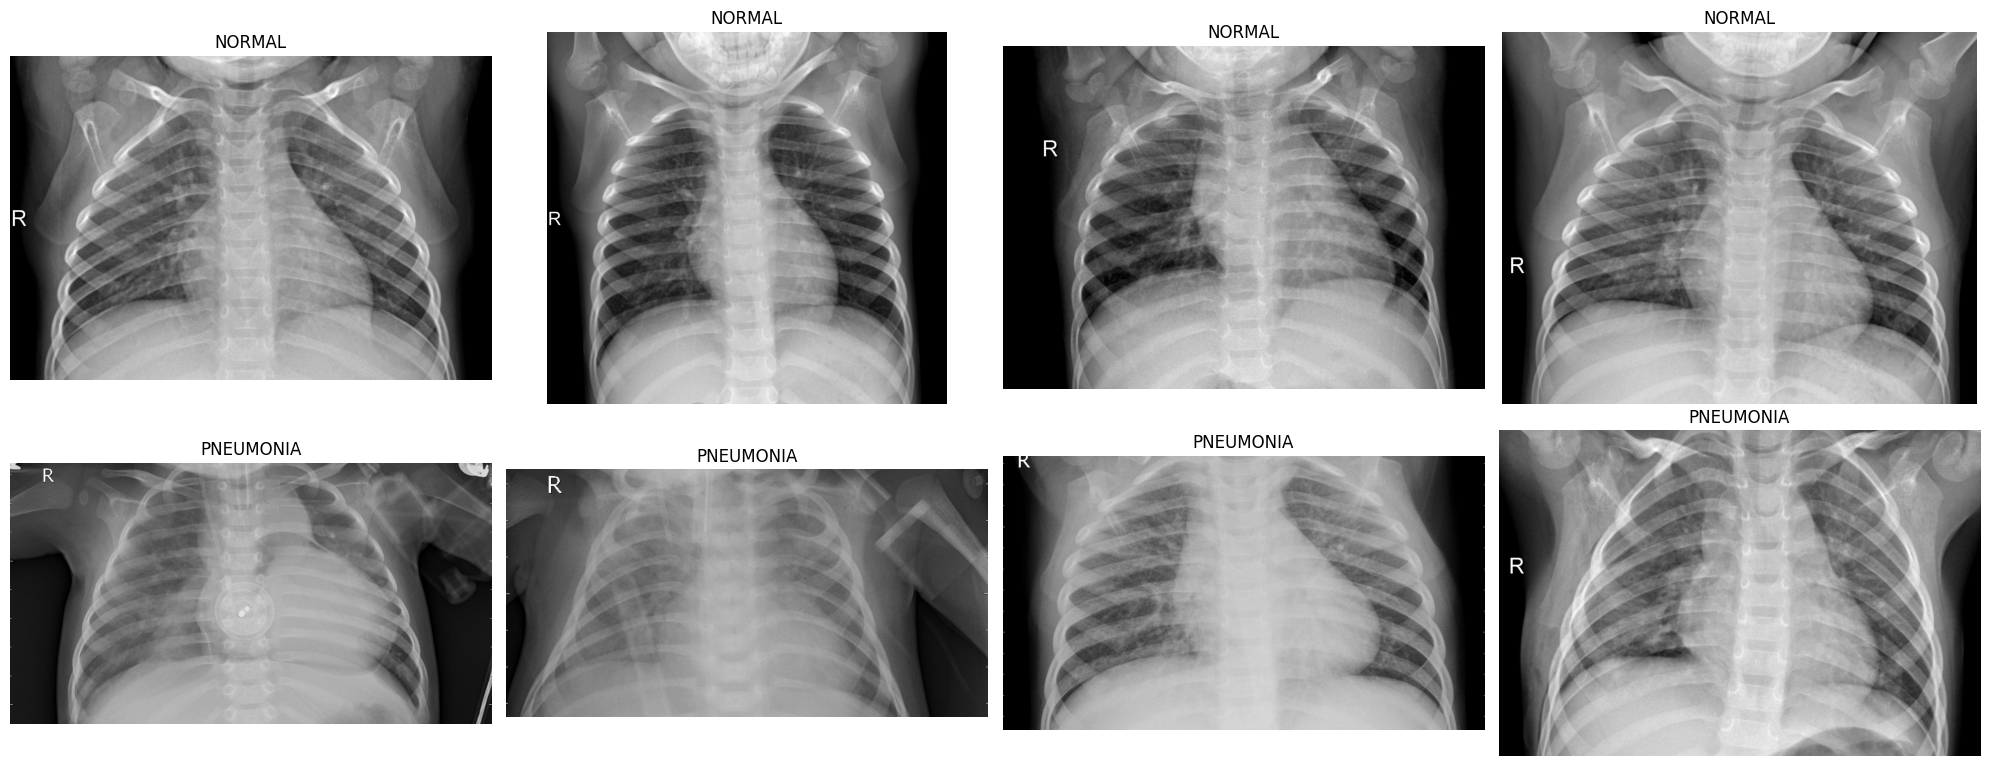

In [2]:
path="./X-Ray"
xray={}
for class_name in os.listdir(path):
    class_path=os.path.join(path, class_name)
    if os.path.isdir(class_path):
        xray[class_name]=os.listdir(class_path)


fig, axes=plt.subplots(len(xray), 4, figsize=(20, 4 *len(xray)))
if len(xray)==1:
    axes=[axes]

for i, class_name in enumerate(xray.keys()):
    images_list=xray[class_name]
    num_samples=min(4, len(images_list))

    images=np.random.choice(images_list, num_samples, replace=False)

    for j, image_name in enumerate(images):
        img_path=os.path.join(path, class_name, image_name)
        img=Image.open(img_path)
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(class_name)
        axes[i][j].axis('off')
    
    for k in range(num_samples, 4):
        axes[i][k].axis('off')

plt.tight_layout()
plt.show()

## Augmentation Process

### Distribution of Image Per Class Before Augmentation

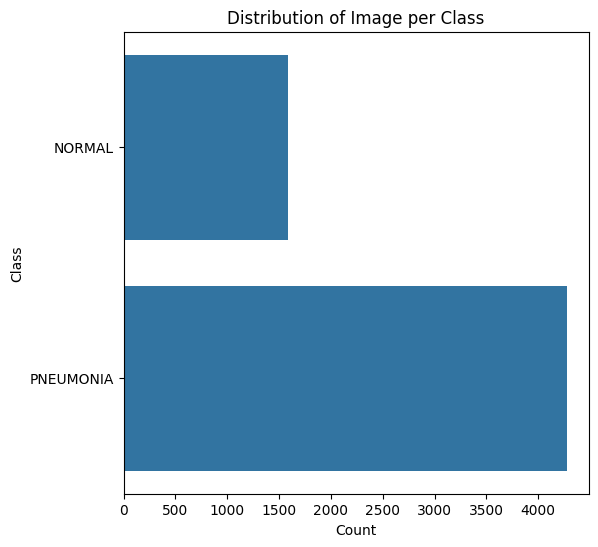

In [ ]:
x_ray="./X-Ray"
file_name=[]
labels=[]
full_path=[]

for path, subdirs, files in os.walk(x_ray):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

distribution=pd.DataFrame({"path":full_path, "file_name":file_name, "Labels":labels})

plt.figure(figsize=(6,6))
sns.countplot(data=distribution, y='Labels')
plt.title('Distribution of Image per Class')
plt.xlabel('Count')
plt.ylabel('Class')
plt.show()

### Data Augmentation Process

In [4]:
augment_balance(
    base_path='./X-Ray',
    categories=['NORMAL'],
    num_images=2500
)

### Distribution of Image per Class After Augmentation

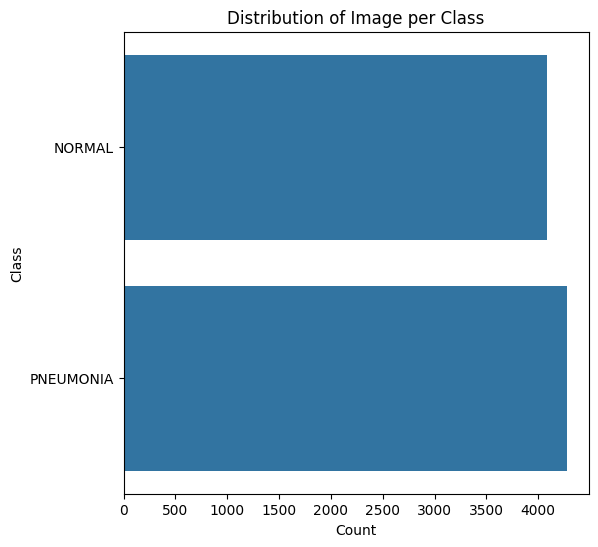

In [2]:
x_ray="./X-Ray"
file_name=[]
labels=[]
full_path=[]

for path, subdirs, files in os.walk(x_ray):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

distribution=pd.DataFrame({"path":full_path, "file_name":file_name, "Labels":labels})
plt.figure(figsize=(6,6))
sns.countplot(data=distribution, y='Labels')
plt.title('Distribution of Image per Class')
plt.xlabel('Count')
plt.ylabel('Class')
plt.show()

## Split Data Train and Data Test

In [3]:
my_path="./X-Ray"
file_name=[]
labels=[]
full_path=[]

for path, subdirs, files in os.walk(my_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

df=pd.DataFrame({"path":full_path, "file_name":file_name, "labels":labels})
df.groupby(['labels']).size()

labels
X-Ray\NORMAL       4083
X-Ray\PNEUMONIA    4273
dtype: int64

In [4]:
X=df['path']
y=df['labels']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [5]:
df_tr=pd.DataFrame({'path':X_train, 'labels':y_train, 'set':'train'})
df_ts=pd.DataFrame({'path':X_test, 'labels':y_test, 'set':'test'})

In [6]:
df_all=pd.concat([df_tr, df_ts], ignore_index=True)
print("============================================\n")
print(df_all.groupby(['set','labels']).size(), '\n')
print("============================================\n")
print(df_all.sample(5))
datasource_path="./X-Ray"
dataset_path='./Final'
os.makedirs(dataset_path, exist_ok=True)


set    labels         
test   X-Ray\NORMAL        825
       X-Ray\PNEUMONIA     847
train  X-Ray\NORMAL       3258
       X-Ray\PNEUMONIA    3426
dtype: int64 


                                              path           labels    set
751       ./X-Ray\NORMAL\NORMAL2-IM-0059-0001.jpeg     X-Ray\NORMAL  train
4767            ./X-Ray\NORMAL\aug_NORMAL_2155.png     X-Ray\NORMAL  train
2611             ./X-Ray\NORMAL\aug_NORMAL_745.png     X-Ray\NORMAL  train
3654  ./X-Ray\PNEUMONIA\person1402_virus_2405.jpeg  X-Ray\PNEUMONIA  train
977               ./X-Ray\NORMAL\aug_NORMAL_95.png     X-Ray\NORMAL  train


In [8]:
for index, row in tq(df_all.iterrows()):

    file_path=row['path']

    if not os.path.exists(file_path):
        file_path=os.path.join(
            datasource_path, 
            row['labels'],
            row['file_name']
        )
    

    dest_dir=os.path.join(dataset_path, row['set'], row['labels'])
    os.makedirs(dest_dir, exist_ok=True)
    
    destination_file_name=os.path.basename(file_path)
    file_dest=os.path.join(dest_dir, destination_file_name)

    if os.path.exists(file_path):
        if not os.path.exists(file_dest):
            shutil.copy(file_path, file_dest)
    else:
        print("File Tidak Ditemukan:", file_path)

0it [00:00, ?it/s]

In [2]:
TRAIN_DIR="./Final/train/X-Ray"
TEST_DIR="./Final/test/X-Ray"

train_normal=os.path.join(TRAIN_DIR +'/NORMAL')
train_pneumonia=os.path.join(TRAIN_DIR + '/PNEUMONIA')
test_normal=os.path.join(TEST_DIR +'/NORMAL')
test_pneumonia=os.path.join(TEST_DIR +'/PNEUMONIA')

print("Total Number of Normal Lung images in Training dataset", len(os.listdir(train_normal)))
print("Total Number of Pneumonia Lung images in Training dataset", len(os.listdir(train_pneumonia)))
print("Total Number of Normal Lung Images in Testing Dataset", len(os.listdir(test_normal)))
print("Total Number of Pneumonia Lung Images in Testing Dataset", len(os.listdir(test_pneumonia)))

Total Number of Normal Lung images in Training dataset 3258
Total Number of Pneumonia Lung images in Training dataset 3426
Total Number of Normal Lung Images in Testing Dataset 825
Total Number of Pneumonia Lung Images in Testing Dataset 847


In [3]:
train_dir='./Final/train/X-Ray'
test_dir='./Final/test/X-Ray'
train_gen, val_gen, test_gen=create_generators(train_dir, test_dir)

Found 5348 images belonging to 2 classes.
Found 1336 images belonging to 2 classes.
Found 1672 images belonging to 2 classes.


## Modelling

In [5]:
model=modeling()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 batch_normalization (Batch  (None, 148, 148, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 74, 74, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 74, 64)        5

## Train Model

In [6]:
history=train_model(
    model,
    train_gen,
    val_gen
)

Epoch 1/50
168/168 [==============================] - 633s 4s/step - loss: 1.2983 - accuracy: 0.7364 - val_loss: 0.3841 - val_accuracy: 0.8391
Epoch 2/50
168/168 [==============================] - 594s 4s/step - loss: 0.3291 - accuracy: 0.8957 - val_loss: 0.3091 - val_accuracy: 0.8660
Epoch 3/50
168/168 [==============================] - 525s 3s/step - loss: 0.1872 - accuracy: 0.9413 - val_loss: 4.1349 - val_accuracy: 0.6579
Epoch 4/50
168/168 [==============================] - ETA: 0s - loss: 0.1575 - accuracy: 0.9525
Training model stopped: val_accuracy 0.91, val_loss0.25
168/168 [==============================] - 484s 3s/step - loss: 0.1575 - accuracy: 0.9525 - val_loss: 0.2471 - val_accuracy: 0.9057


## Evaluation

### Data Train Evaluation

In [7]:
loss, accuracy=model.evaluate(train_gen)
print(f"Accuracy:{accuracy:.4f}")
print(f"Loss:{loss:.4f}")

168/168 [==============================] - 86s 509ms/step - loss: 0.0925 - accuracy: 0.9628
Accuracy:0.9628
Loss:0.0925


### Data Test Evaluation

In [8]:
loss, acccuracy=model.evaluate(test_gen)
print(f"Accuracy:{accuracy:.4f}")
print(f"Loss:{loss:.4f}")

53/53 [==============================] - 35s 661ms/step - loss: 0.1047 - accuracy: 0.9563
Accuracy:0.9628
Loss:0.1047


### Visualization of Accuracy and Loss 

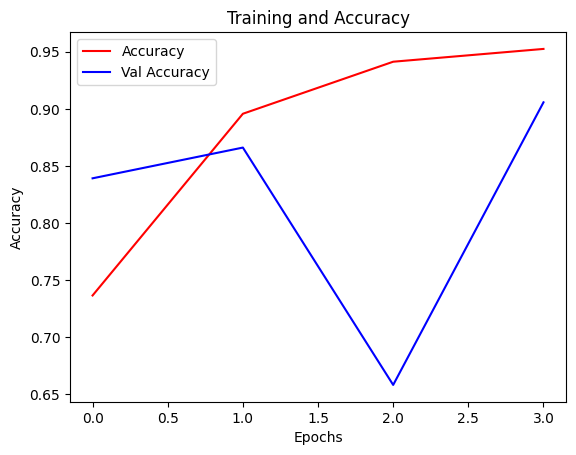

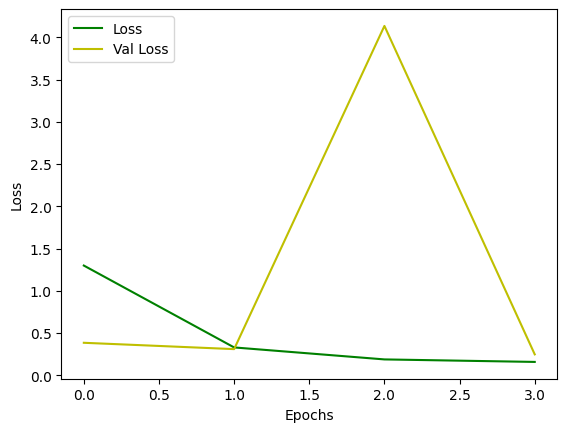

In [9]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc))
plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Accuracy','Val Accuracy'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'g')
plt.plot(epochs, val_loss, 'y')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Loss','Val Loss'], loc='upper left')

plt.show()

### Classification Report and Confusion Matrix

53/53 [==============================] - 32s 601ms/step
Class Name ['NORMAL', 'PNEUMONIA']
Confusion Matrix


<Figure size 600x500 with 0 Axes>

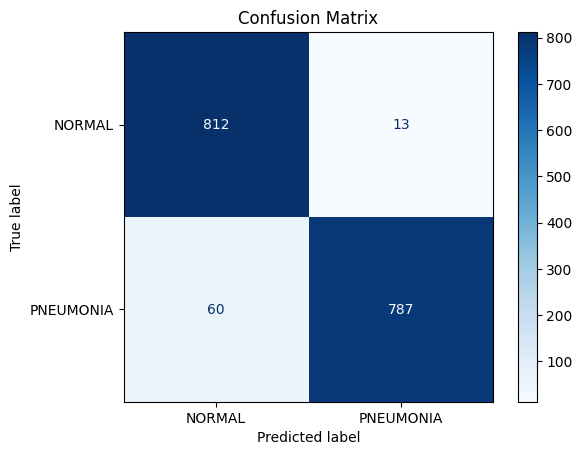

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.93      0.98      0.96       825
   PNEUMONIA       0.98      0.93      0.96       847

    accuracy                           0.96      1672
   macro avg       0.96      0.96      0.96      1672
weighted avg       0.96      0.96      0.96      1672

Accuracy : 95.63%


In [7]:
Y_pred=model.predict(test_gen, verbose=1)
y_pred=(Y_pred > 0.5).astype(int).flatten()

y_true=test_gen.classes

class_names=list(test_gen.class_indices.keys())

print("Class Name", class_names)

print("Confusion Matrix")
cm=confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

print("Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

acc = accuracy_score(y_true, y_pred)
print("Accuracy : {:.2f}%".format(acc * 100))

### Save Model

In [ ]:
os.makedirs('Model')
model.save('./Model/model.h5')

c:\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Testing

## Pneumonia Testing

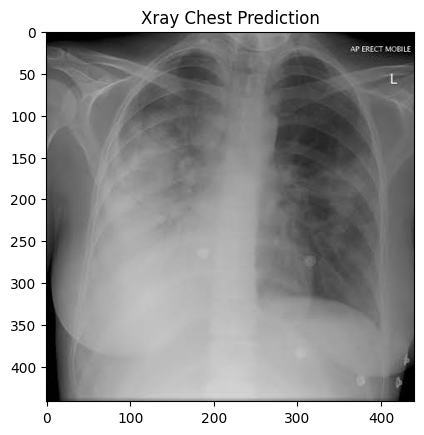

Prediksi: 0.999974250793457
Confidence PNEUMONIA


In [2]:
model=load_model('./Model/model.h5')

label, confidence=predict_image(
    model,
    "./Testing/Pneumonia.jpeg",
    classes=['NORMAL','PNEUMONIA']
)

img=Image.open('./Testing/Pneumonia.jpeg')
plt.imshow(img)
plt.title('Xray Chest Prediction')
plt.show()
print("Prediksi:",label)
print("Confidence",confidence)

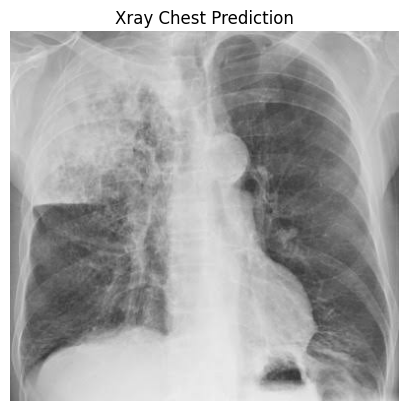

Prediksi: 0.9759839177131653
Confidence PNEUMONIA


In [3]:
model=load_model('./Model/model.h5')
label, confidence=predict_image(
    model,
    "./Testing/Pneumonia 1.jpeg",
    classes=['NORMAL','PNEUMONIA']
)
img=Image.open('./Testing/Pneumonia 1.jpeg')
plt.imshow(img)
plt.title('Xray Chest Prediction')
plt.axis('off')
plt.show()
print("Prediksi:",label)
print("Confidence", confidence)

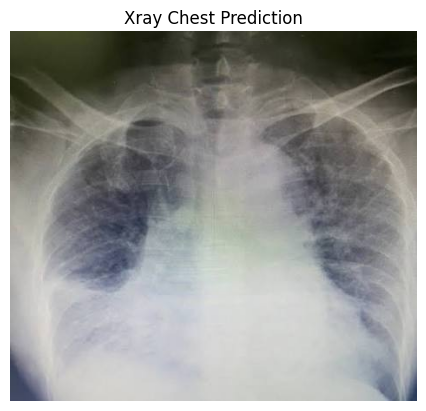

Prediksi: 0.9465157985687256
Confidence: PNEUMONIA


In [5]:
model=load_model('./Model/model.h5')

label, confidence=predict_image(
    model, 
    "./Testing/Pneumonia_2.jpeg",
    classes=['NORMAL', 'PNEUMONIA']
)

img=Image.open('./Testing/Pneumonia_2.jpeg')
plt.imshow(img)
plt.title('Xray Chest Prediction')
plt.axis('off')
plt.show()
print("Prediksi:",label)
print("Confidence:",confidence)


### Normal Testing

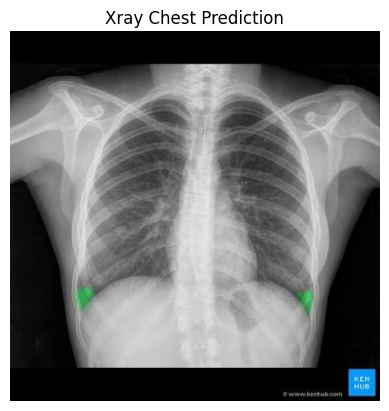

Prediksi: 0.9999999999672008
Confidence: NORMAL


In [6]:
model=load_model('./Model/model.h5')

label, confidence=predict_image(
    model, 
    "./Testing/Normal.jpeg",
    classes=['NORMAL', 'PNEUMONIA']
)

img=Image.open('./Testing/Normal.jpeg')
plt.imshow(img)
plt.title('Xray Chest Prediction')
plt.axis('off')
plt.show()
print("Prediksi:",label)
print("Confidence:",confidence)


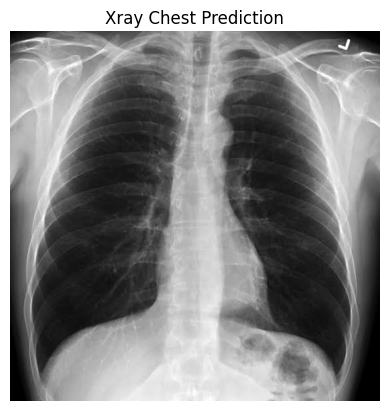

Label 0.9999999891210205
Confidence NORMAL


In [7]:
model=load_model('./Model/model.h5')

label, confidence=predict_image(
    model,
    './Testing/Normal 1.jpeg',
    classes=['NORMAL','PNEUMONIA']
)
img=Image.open('./Testing/Normal 1.jpeg')
plt.imshow(img)
plt.title('Xray Chest Prediction')
plt.axis('off')
plt.show()
print("Label",label)
print("Confidence", confidence)